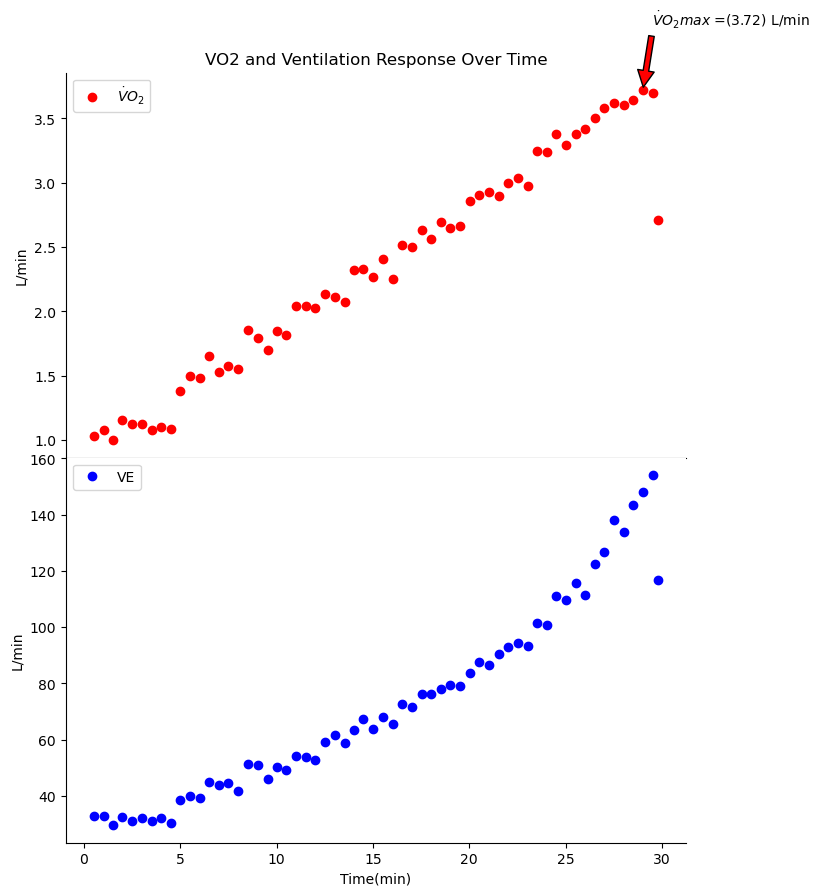

In [1]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


df = pd.read_csv('../input/demo-knes381/subject_1432.csv', header=[0], skiprows=[1,2,3])


df = df.rename(columns={'VE/': 'VE/VO2','VE/.1': 'VE/VCO2'})


x = df['TIME']
y = df['VO2']
y1 = df['VE']


ymax = max(y)


xmax = x[y.argmax()]

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 10)) 


fig.subplots_adjust(hspace=0)



ax[0].annotate('$\dot VO_2max$ =({}) L/min'.format(round(ymax, 2)), 
               xy=(xmax, ymax), xytext=(xmax+.5, ymax+ .5),
               arrowprops=dict(facecolor='red', shrink= 0.05),
                )

ax[0].plot(x, y, 'o', label=('$\dot VO_2$'), c='r' )

ax[0].set_title('VO2 and Ventilation Response Over Time')
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set(ylabel=('L/min'))
ax[0].legend()

ax[1].plot(x, y1, 'o', label=('VE'), c='b')
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].set(ylabel=('L/min'))
ax[1].set(xlabel=('Time(min)'))
ax[1].legend()


fig.savefig("VO2-VE-4.png", dpi=300, bbox_inches = "tight")
fig.show()



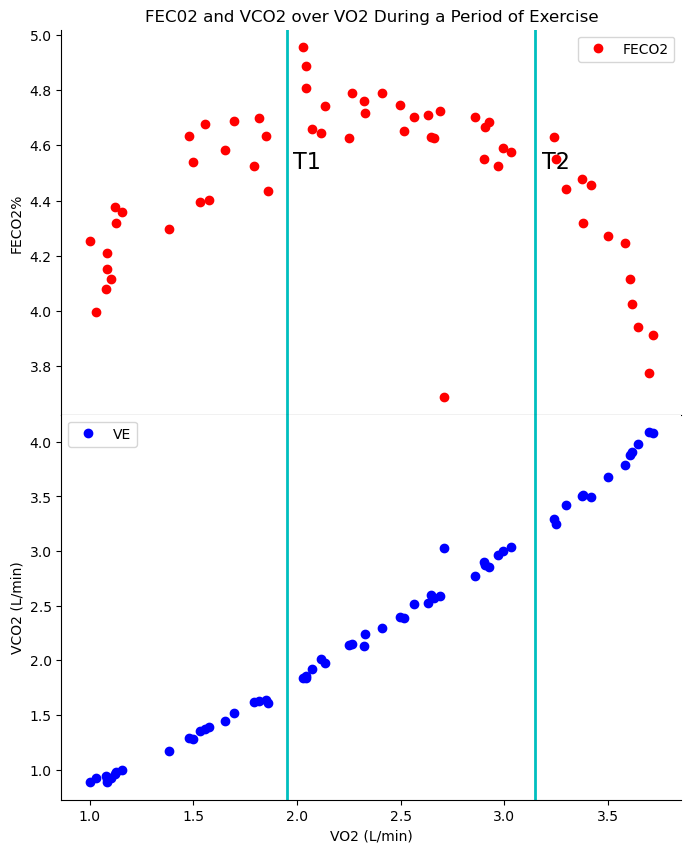

In [2]:
y2 = df ['FECO2']
y3 = df ['VCO2']
fig, bx = plt.subplots(2, 1, sharex=True, figsize=(8, 10)) 


fig.subplots_adjust(hspace=0)


bx[0].plot(y, y2, 'o', label=('FECO2'), c='r' )

bx[0].set_title('FEC02 and VCO2 over VO2 During a Period of Exercise')
bx[0].spines['right'].set_visible(False)
bx[0].spines['top'].set_visible(False)
bx[0].set(ylabel=('FECO2%'))
bx[0].legend()

bx[1].plot(y, y3, 'o', label=('VE'), c='b')
bx[1].spines[['top', 'right']].set_visible(False)
bx[1].set(ylabel=('VCO2 (L/min)'))
bx[1].set(xlabel=('VO2 (L/min)'))
bx[1].legend()

T1 = 1.95
T2 = 3.15

for a in bx:
    a.axvline(T1, color='c', linewidth=2)
    a.axvline(T2, color='c', linewidth=2)

ymax = bx [0].get_ylim()[1]

bx[0].text(T1 + 0.03, ymax*0.9, 'T1' , fontsize=16, color='black')
bx[0].text(T2 + 0.03, ymax*0.9, 'T2' , fontsize=16, color='black')


fig.show()